In [ ]:
import os
import time
import urllib.request

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 69
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")

torch 2.14.0+cpu | device: cpu


## Task 1

### Task 1.1 Descarga y preprocesamiento

In [ ]:
URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
if not os.path.exists("ETTh1.csv"):          # evita descargar de nuevo si ya existe
    urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT  = data[:, -1].astype(np.float32)   # Oil Temperature: columna objetivo
ALL = data[:, 1:].astype(np.float32)   # 7 variables (6 de carga + OT)

print(f"Observaciones horarias: {len(OT)}")
print(f"ALL shape: {ALL.shape}")
print(f"OT: min={OT.min():.3f}  max={OT.max():.3f}  media={OT.mean():.3f}")

Observaciones horarias: 17420  (~1.99 años)
ALL shape: (17420, 7)
OT: min=-4.080  max=46.007  media=13.325


#### a. Normalización z-score.

Cada valor se transforma como

$$\tilde{x}_t = \frac{x_t - \mu}{\sigma}$$

Se guardan `mu` y `sigma` para desnormalizar las predicciones a evaluar

In [3]:
# a. z-score: x_norm = (x - mu) / sigma
mu    = float(OT.mean())
sigma = float(OT.std())
OT_norm = torch.tensor((OT - mu) / sigma, dtype=torch.float32)


def denorm(z):
    # Inversa del z-score: x = z * sigma + mu  (regresa a grados Celsius)
    return z * sigma + mu


print(f"mu = {mu:.4f} °C   sigma = {sigma:.4f} °C")
print(f"OT_norm: media={OT_norm.mean().item():.2e}  std={OT_norm.std(unbiased=False).item():.4f}")

mu = 13.3247 °C   sigma = 8.5667 °C
OT_norm: media=-2.02e-08  std=1.0000


#### b. Split temporal contiguo

(60% / 20% / 20%), sin mezcla aleatoria: el modelo solo ve el pasado al entrenar y se evalúa en el futuro.

In [ ]:
# b. Split temporal: bloques contiguos [0, n_tr) | [n_tr, n_tr+n_vl) | [n_tr+n_vl, n)
n    = len(OT_norm)
n_tr = int(0.6 * n)
n_vl = int(0.2 * n)

OT_train = OT_norm[:n_tr]
OT_val   = OT_norm[n_tr:n_tr + n_vl]
OT_test  = OT_norm[n_tr + n_vl:]          # el resto (~20%)

print(f"train: {len(OT_train):>6}  ({len(OT_train)/n:.1%})  indices [0, {n_tr})")
print(f"val  : {len(OT_val):>6}  ({len(OT_val)/n:.1%})  indices [{n_tr}, {n_tr + n_vl})")
print(f"test : {len(OT_test):>6}  ({len(OT_test)/n:.1%})  indices [{n_tr + n_vl}, {n})")

train:  10452  (60.0%)  indices [0, 10452)
val  :   3484  (20.0%)  indices [10452, 13936)
test :   3484  (20.0%)  indices [13936, 17420)


#### c. Ventaneo

Para cada instante $t$ se construye el par

$$X^{(t)} = (x_{t-L+1}, \dots, x_t), \qquad y^{(t)} = x_{t+H}$$

El primer $t$ válido es $t = L-1$ (hay $L$ valores de historia) y el último es $t = N-1-H$ (existe el objetivo $x_{t+H}$), por lo que se obtienen $N - L - H + 1$ ejemplos por split.

In [ ]:
def make_windows(series, L, H):
    # Parametros
    # series : serie 1D (tensor o array) de longitud N
    # L: longitud de la ventana de historia
    # H: horizonte de prediccion
    #
    # Retorna
    # X: Tensor (N_w, L)  con X^(t) = (x_{t-L+1}, ..., x_t)
    # y: Tensor (N_w,)    con y^(t) = x_{t+H}
    series = torch.as_tensor(series, dtype=torch.float32)
    N = series.shape[0]
    N_w = N - L - H + 1
    assert N_w > 0, "La serie es demasiado corta para L y H dados"

    # unfold genera todas las ventanas deslizantes de largo L con paso 1:
    # la fila j es (x_j, ..., x_{j+L-1}), es decir, termina en t = j + L - 1
    X = series.unfold(0, L, 1)[:N_w].clone()
    # el objetivo de la fila j es x_{t+H} = x_{j+L-1+H}
    y = series[L - 1 + H: L - 1 + H + N_w].clone()
    return X, y

L = 96

# H = 24
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val,   L, 24)
X_te_24, y_te_24 = make_windows(OT_test,  L, 24)

# H = 48
X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val,   L, 48)
X_te_48, y_te_48 = make_windows(OT_test,  L, 48)

for H, (Xtr, Xvl, Xte) in {24: (X_tr_24, X_vl_24, X_te_24),
                           48: (X_tr_48, X_vl_48, X_te_48)}.items():
    print(f"H={H}: X_tr {tuple(Xtr.shape)} | X_vl {tuple(Xvl.shape)} | X_te {tuple(Xte.shape)}")

t = L - 1
assert torch.equal(X_tr_24[0], OT_train[t - L + 1: t + 1])
assert y_tr_24[0] == OT_train[t + 24]

H=24: X_tr (10333, 96) | X_vl (3365, 96) | X_te (3365, 96)
H=48: X_tr (10309, 96) | X_vl (3341, 96) | X_te (3341, 96)


Baseline naive (persistencia). Predice que el valor dentro de $H$ horas será igual al último observado: $\hat{y}^{(t)} = x_t$ = `X[:, -1]`. Sirve como referencia: un modelo útil debe tener ratio `MAE_modelo / MAE_naive` < 1.

In [6]:
def naive_metrics(X, y):
    # Persistencia: y_hat = x_t (ultimo valor de la ventana)
    y_hat = X[:, -1]
    mae  = torch.abs(y - y_hat).mean().item()
    rmse = torch.sqrt(((y - y_hat) ** 2).mean()).item()
    return mae, rmse


for H, (Xv, yv) in {24: (X_vl_24, y_vl_24), 48: (X_vl_48, y_vl_48)}.items():
    mae, rmse = naive_metrics(Xv, yv)
    print(f"Naive val H={H}: MAE={mae:.4f} (norm) = {mae * sigma:.3f} °C | "
          f"RMSE={rmse:.4f} (norm) = {rmse * sigma:.3f} °C")

Naive val H=24: MAE=0.1996 (norm) = 1.710 °C | RMSE=0.2672 (norm) = 2.289 °C
Naive val H=48: MAE=0.2604 (norm) = 2.231 °C | RMSE=0.3359 (norm) = 2.878 °C


### Task 1.2 Función de autocorrelación (ACF)

#### a. ACF manual:

El numerador es la autocovarianza al lag $k$ (promediada sobre los $N-k$ pares disponibles) y el denominador es la varianza (autocovarianza al lag 0), por lo que $\rho(0) = 1$.

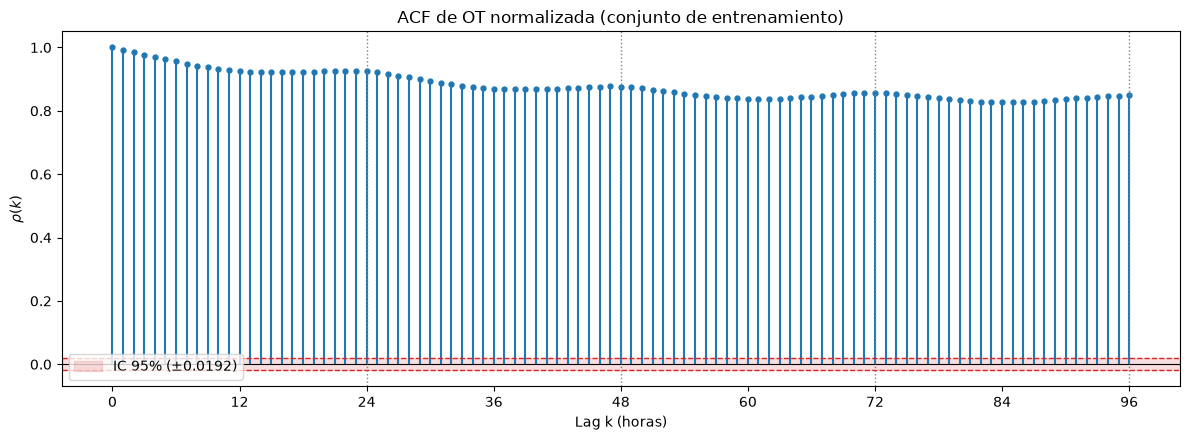

N = 10452,  banda 95% = ±0.0192
rho(k) en lags clave:
  k= 1: 0.9923
  k= 6: 0.9558
  k=12: 0.9250
  k=18: 0.9228
  k=24: 0.9250
  k=36: 0.8695
  k=48: 0.8763
  k=72: 0.8572
  k=96: 0.8489
Lags significativos (|rho| > banda): 96 de 96


In [ ]:
def acf_manual(series, max_lag):
    # Calcula rho(k) para k = 0, 1, ..., max_lag segun la formula de la celda anterior
    x = np.asarray(series, dtype=np.float64)
    N = len(x)
    x_bar = x.mean()
    d = x - x_bar # (x_t - x_bar)

    gamma0 = (d ** 2).sum() / N # denominador: (1/N) sum (x_t - x_bar)^2

    acf = np.empty(max_lag + 1)
    for k in range(max_lag + 1):
        # numerador: (1/(N-k)) sum_{t=k}^{N-1} (x_t - x_bar)(x_{t-k} - x_bar)
        # d[k:] recorre x_t con t = k..N-1  y  d[:N-k] recorre x_{t-k}
        gamma_k = (d[k:] * d[:N - k]).sum() / (N - k)
        acf[k] = gamma_k / gamma0
    return acf


max_lag = 96
acf_train = acf_manual(OT_train.numpy(), max_lag)
N_acf = len(OT_train)
conf = 1.96 / np.sqrt(N_acf) # banda de confianza al 95%: +-1.96/sqrt(N)

fig, ax = plt.subplots(figsize=(12, 4.5))
lags = np.arange(max_lag + 1)
ax.vlines(lags, 0, acf_train, color="tab:blue", lw=1.5)
ax.plot(lags, acf_train, "o", color="tab:blue", ms=3.5)
ax.axhline(0, color="black", lw=0.8)
ax.axhspan(-conf, conf, color="tab:red", alpha=0.15, label=f"IC 95% (±{conf:.4f})")
ax.axhline(conf, color="tab:red", ls="--", lw=1)
ax.axhline(-conf, color="tab:red", ls="--", lw=1)
for k in (24, 48, 72, 96):
    ax.axvline(k, color="gray", ls=":", lw=1)
ax.set_xticks(range(0, max_lag + 1, 12))
ax.set_xlabel("Lag k (horas)")
ax.set_ylabel(r"$\rho(k)$")
ax.set_title("ACF de OT normalizada (conjunto de entrenamiento)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"N = {N_acf},  banda 95% = ±{conf:.4f}")
print("rho(k) en lags clave:")
for k in (1, 6, 12, 18, 24, 36, 48, 72, 96):
    print(f"  k={k:>2}: {acf_train[k]:.4f}")
print(f"Lags significativos (|rho| > banda): {(np.abs(acf_train[1:]) > conf).sum()} de {max_lag}")

In [8]:
# Picos de la ACF: maximos locales rho(k-1) < rho(k) > rho(k+1), excluyendo lag 0
peaks = [k for k in range(1, max_lag) if acf_train[k] > acf_train[k - 1] and acf_train[k] > acf_train[k + 1]]
peaks_sorted = sorted(peaks, key=lambda k: acf_train[k], reverse=True)

print("Maximos locales de la ACF (ordenados por rho):")
for k in peaks_sorted:
    print(f"  lag {k:>2}: rho = {acf_train[k]:.4f}")

second_peak = peaks_sorted[0]
print(f"\nSegundo pico mas alto (despues de lag 0): lag {second_peak}, rho = {acf_train[second_peak]:.4f}")

# Valles (minimos locales) para cuantificar la oscilacion diaria
troughs = [k for k in range(1, max_lag) if acf_train[k] < acf_train[k - 1] and acf_train[k] < acf_train[k + 1]]
print("Minimos locales:", [(k, round(float(acf_train[k]), 4)) for k in troughs])

Maximos locales de la ACF (ordenados por rho):
  lag 22: rho = 0.9262
  lag 47: rho = 0.8770
  lag 72: rho = 0.8572

Segundo pico mas alto (despues de lag 0): lag 22, rho = 0.9262
Minimos locales: [(15, 0.9211), (38, 0.8675), (61, 0.837), (84, 0.8266)]


### Verificación Task 1

In [9]:
# Ejecute esta celda para verificar su implementacion
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)
